In [1]:
!pip install pandas scikit-learn joblib requests

In [2]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import joblib

In [3]:
df=pd.read_csv('router_combined_data_v2.csv')

In [4]:
df.head()

,text,label
0,Could you Are we low on anything? for me,forecast
1,Can you Predict demand for clothing category f...,forecast
2,Can you Will ABC-789 be available next week? ASAP,forecast
3,"Hey, Predict inventory for Mansoura store now",forecast
4,Tell me Can you forecast demand for next week?,forecast


In [5]:
model = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(ngram_range=(1, 2))
    ),

    (
        "classifier",
        LogisticRegression(max_iter=1000)
    )
])

In [6]:
from sklearn.model_selection import train_test_split

# Define feature and target variables based on your dataset columns
X = df['text']
y = df['label']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the pipeline
model.fit(X_train, y_train)

# Evaluate model accuracy
accuracy = model.score(X_test, y_test)
print(f"Test Set Accuracy: {accuracy:.4f}")

Test Set Accuracy: 0.9855


In [7]:
# Check training accuracy vs test accuracy
train_acc = model.score(X_train, y_train)
test_acc = accuracy
print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

# Check for duplicate entries causing near-identical train/test rows
duplicates = df.duplicated(subset=['text']).sum()
print(f"Total rows: {len(df)} | Duplicate text rows: {duplicates}")

# Check label distribution
print("\nLabel Distribution:\n", df['label'].value_counts(normalize=True))

Train Accuracy: 0.9964 | Test Accuracy: 0.9855
Total rows: 1032 | Duplicate text rows: 0

Label Distribution:
 label
forecast    0.25
decision    0.25
vision      0.25
rag         0.25
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, df["text"], df["label"], cv=5)
print(f"Mean CV Accuracy: {scores.mean() * 100:.2f}%")

Mean CV Accuracy: 98.74%


In [9]:
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9855072463768116
              precision    recall  f1-score   support

    decision       0.96      1.00      0.98        51
    forecast       1.00      0.94      0.97        49
         rag       0.98      1.00      0.99        56
      vision       1.00      1.00      1.00        51

    accuracy                           0.99       207
   macro avg       0.99      0.98      0.99       207
weighted avg       0.99      0.99      0.99       207



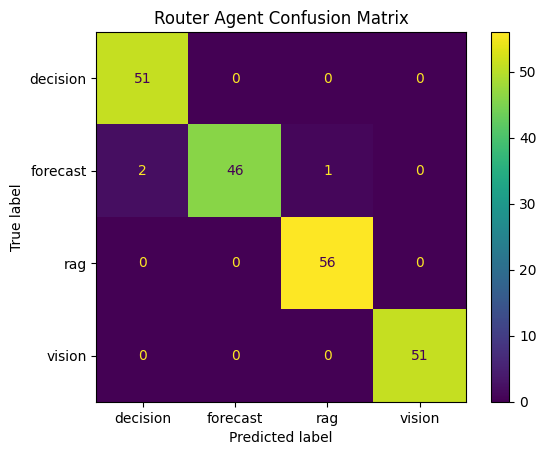

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Router Agent Confusion Matrix")
plt.show()

In [12]:
import joblib

joblib.dump(model, "router_model.pkl")

['router_model.pkl']

In [13]:
loaded_model = joblib.load("router_model.pkl")

question = "إيه المنتجات اللي هتخلص قريب؟"

prediction = loaded_model.predict([question])[0]

print(prediction)

forecast


In [14]:
class RouterAgent:
    def __init__(self, model):
        self.model = model

    def classify(self, query):
        return self.model.predict([query])[0]


router = RouterAgent(loaded_model)

In [15]:
import requests
import random

def forecast_agent(query, context=None, language="en"):

    context = context or {}

    product_id = context.get("product_id", "P001")
    store_id = context.get("store_id", "S001")
    days_ahead = context.get("days_ahead", 7)

    try:
        response = requests.post(
            "http://localhost:8000/predict/forecast",
            json={
                "product_id": product_id,
                "store_id": store_id,
                "days_ahead": days_ahead
            },
            timeout=5
        )

        if response.status_code == 200:
            data = response.json()

            forecast = data.get("forecast", [])
            confidence = data.get("confidence", 0.85)

            return _format_forecast_response(
                forecast,
                confidence,
                product_id,
                days_ahead,
                language
            )

        else:
            return _mock_forecast_response(product_id, days_ahead, language)

    except (requests.exceptions.Timeout,
            requests.exceptions.ConnectionError):

        return _mock_forecast_response(product_id, days_ahead, language)

    except Exception as e:

        return f"Error getting forecast: {str(e)}"


def _format_forecast_response(
    forecast,
    confidence,
    product_id,
    days_ahead,
    language
):
    total = sum(forecast)
    average = total / len(forecast)
    highest = max(forecast)
    lowest = min(forecast)

    # Determine demand level
    if average >= 15:
        demand_level_en = "very high"
        demand_level_ar = "مرتفع جدًا"
    elif average >= 10:
        demand_level_en = "high"
        demand_level_ar = "مرتفع"
    elif average >= 5:
        demand_level_en = "moderate"
        demand_level_ar = "متوسط"
    else:
        demand_level_en = "low"
        demand_level_ar = "منخفض"

    # Arabic response
    if language == "ar":
        return (
            f"بالنسبة للمنتج {product_id}، من المتوقع أن يكون الطلب "
            f"{demand_level_ar} خلال الـ {days_ahead} أيام القادمة. "
            f"متوسط الطلب اليومي: {average:.1f} وحدة. "
            f"أعلى طلب في يوم واحد: {highest} وحدة. "
            f"أقل طلب في يوم واحد: {lowest} وحدة. "
            f"إجمالي الطلب المتوقع: {total} وحدة. "
            f"نسبة الثقة: {confidence:.0%}."
        )

    # English response
    return (
        f"For product {product_id}, demand is predicted to be "
        f"{demand_level_en} over the next {days_ahead} days. "
        f"Average daily demand: {average:.1f} units. "
        f"Highest day: {highest} units. "
        f"Lowest day: {lowest} units. "
        f"Total forecast: {total} units. "
        f"Confidence: {confidence:.0%}."
    )


def _mock_forecast_response(product_id, days_ahead, language):

    base_demand = random.randint(8, 20)

    forecast = [
        base_demand + random.randint(-3, 3)
        for _ in range(days_ahead)
    ]

    confidence = random.uniform(0.80, 0.95)

    return _format_forecast_response(
        forecast,
        confidence,
        product_id,
        days_ahead,
        language
    )


def decision_agent(query, context=None):

    context = context or {}

    current_stock = context.get("current_stock", 50)
    forecast = context.get(
        "forecast",
        [10, 12, 8, 15, 20, 14, 16]
    )
    product_id = context.get("product_id", "P001")

    try:
        response = requests.post(
            "http://localhost:8000/predict/decision",
            json={
                "forecast": forecast,
                "current_stock": current_stock,
                "holding_cost": 2.0,
                "stockout_cost": 100.0
            },
            timeout=5
        )

        if response.status_code == 200:

            data = response.json()

            order_quantity = data.get(
                "order_quantity",
                0
            )

            total_cost = data.get(
                "total_cost",
                0
            )

            return _format_decision_response(
                order_quantity,
                total_cost,
                current_stock,
                product_id
            )

        else:
            return _mock_decision_response(
                product_id,
                current_stock
            )

    except (requests.exceptions.Timeout,
            requests.exceptions.ConnectionError):

        return _mock_decision_response(
            product_id,
            current_stock
        )

    except Exception as e:

        return f"Error optimizing order: {str(e)}"


def _format_decision_response(
    order_quantity,
    total_cost,
    current_stock,
    product_id
):

    response = (
        f"For product {product_id}, I recommend "
        f"ordering {order_quantity} units. "
        f"Your current stock is {current_stock} units. "
        f"Estimated total cost: ${total_cost:.2f}."
    )

    return response


def _mock_decision_response(
    product_id,
    current_stock
):

    forecast = [10, 12, 8, 15, 20, 14, 16]

    total_demand = sum(forecast)

    order_quantity = max(
        0,
        total_demand - current_stock
    )

    order_quantity = (
        (order_quantity + 9) // 10
    ) * 10

    if order_quantity < 10:
        order_quantity = 0

    return _format_decision_response(
        order_quantity,
        150.0,
        current_stock,
        product_id
    )


def vision_agent(query, context=None):

    context = context or {}

    image_url = context.get("image_url")

    try:

        if image_url:

            response = requests.post(
                "http://localhost:8000/predict/vision",
                json={
                    "image_url": image_url
                },
                timeout=5
            )

            if response.status_code == 200:

                data = response.json()

                detections = data.get(
                    "detections",
                    []
                )

                return _format_vision_response(
                    detections
                )

        return _mock_vision_response()

    except (requests.exceptions.Timeout,
            requests.exceptions.ConnectionError):

        return _mock_vision_response()

    except Exception as e:

        return f"Error detecting packages: {str(e)}"


def _format_vision_response(detections):

    if not detections:
        return "I couldn't detect any packages in the image."

    count = len(detections)

    response = (
        f"I found {count} package"
        f"{'s' if count > 1 else ''} in the image. "
    )

    for i, detection in enumerate(detections[:3]):

        class_name = detection.get(
            "class",
            "package"
        )

        confidence = detection.get(
            "confidence",
            0.9
        ) * 100

        response += (
            f"Package {i + 1}: "
            f"{class_name} "
            f"({confidence:.0f}% confidence). "
        )

    return response


def _mock_vision_response():

    number_of_packages = random.randint(1, 4)

    classes = [
        "box",
        "crate",
        "pallet",
        "carton"
    ]

    detections = [
        {
            "class": random.choice(classes),
            "confidence": random.uniform(
                0.85,
                0.98
            )
        }
        for _ in range(number_of_packages)
    ]

    return _format_vision_response(
        detections
    )


def rag_agent(query, context=None):

    context = context or {}

    try:

        response = requests.post(
            "http://localhost:8000/predict/rag",
            json={
                "query": query,
                "context": context
            },
            timeout=5
        )

        if response.status_code == 200:

            data = response.json()

            return data.get(
                "answer",
                "I couldn't find an answer to that question."
            )

        return _mock_rag_response(query)

    except (requests.exceptions.Timeout,
            requests.exceptions.ConnectionError):

        return _mock_rag_response(query)

    except Exception as e:

        return f"Error querying knowledge base: {str(e)}"


def _mock_rag_response(query):

    query_lower = query.lower()

    if any(
        word in query_lower
        for word in ["inventory", "stock", "supply"]
    ):

        return (
            "The inventory policy uses Economic Order "
            "Quantity with safety stock. Orders are placed "
            "when stock reaches the reorder point."
        )

    elif any(
        word in query_lower
        for word in ["policy", "reorder"]
    ):

        return (
            "The company follows a just-in-time inventory "
            "policy with safety stock. Replenishment is "
            "triggered when inventory falls below the "
            "reorder point."
        )

    else:

        return (
            "Our system uses AI-powered forecasting "
            "to predict demand and optimize ordering."
        )


In [16]:
def route_query(query, context=None, language="en"):
    intent = router.classify(query)

    if intent == "forecast":
        return forecast_agent(query, context, language=language)

    elif intent == "decision":
        return decision_agent(query, context)

    elif intent == "vision":
        return vision_agent(query, context)

    elif intent == "rag":
        return rag_agent(query, context)

    else:
        return "I couldn't determine the correct agent."

In [59]:
def handle_query(text=None, audio_file=None, language="ar", context=None):
    """Main pipeline handler: transcribes audio (if provided), routes query, and generates speech output."""
    if audio_file:
        text = transcribe_audio(audio_file, language=language)

    if not text:
        return "No text or audio query provided."


    answer = route_query(text, context=context, language=language)

    text_to_speech(answer, output_file="final_answer.mp3", language=language)

    return answer

In [18]:
!pip install -U cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.5/370.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.2 MB/s eta 0:00:00


In [19]:
import os
from getpass import getpass

os.environ["COHERE_API_KEY"] = getpass("Enter your Cohere API key: ")

Enter your Cohere API key: ··········


In [20]:
import cohere

co = cohere.ClientV2(os.environ["COHERE_API_KEY"])

In [21]:
import os

print(os.listdir())

['.config', 'answer.mp3', 'router_combined_data_v2.csv', 'project.mp3.mp3', 'router_model.pkl', 'final_answer.mp3', 'sample_data']


In [22]:
with open("project.mp3.mp3", "rb") as f:
    response = co.audio.transcriptions.create(
        model="cohere-transcribe-arabic-07-2026",
        language="ar",
        file=f
    )

print(response)

text=' ايه المنتجات اللي هتخلص الاسبوع الجاي'


In [23]:
text = response.text

print("Transcribed text:", text)

intent = router.classify(text)

print("Intent:", intent)

Transcribed text:  ايه المنتجات اللي هتخلص الاسبوع الجاي
Intent: forecast


In [24]:
result = route_query(text)

print("Final result:", result)

Final result: For product P001, demand is predicted to be very high over the next 7 days. Average daily demand: 15.6 units. Highest day: 18 units. Lowest day: 13 units. Total forecast: 109 units. Confidence: 88%.


In [25]:
!npm install -g voipi

⠙⠹⠸⠼⠴⠦⠧⠇
added 1 package in 2s
⠇

In [26]:
!voipi --version

node:internal/util/parse_args/parse_args:107
      throw new ERR_PARSE_ARGS_UNKNOWN_OPTION(
            ^

TypeError [ERR_PARSE_ARGS_UNKNOWN_OPTION]: Unknown option '--version'. To specify a positional argument starting with a '-', place it at the end of the command after '--', as in '-- "--version"
    at checkOptionUsage (node:internal/util/parse_args/parse_args:107:13)
    at node:internal/util/parse_args/parse_args:381:9
    at Array.forEach (<anonymous>)
    at parseArgs (node:internal/util/parse_args/parse_args:378:3)
    at file:///tools/node/lib/node_modules/voipi/dist/cli/index.mjs:914:33
    at ModuleJob.run (node:internal/modules/esm/module_job:263:25)
    at async ModuleLoader.import (node:internal/modules/esm/loader:540:24)
    at async asyncRunEntryPointWithESMLoader (node:internal/modules/run_main:117:5) {
  code: 'ERR_PARSE_ARGS_UNKNOWN_OPTION'
}

Node.js v20.19.0


In [27]:
!voipi --version

node:internal/util/parse_args/parse_args:107
      throw new ERR_PARSE_ARGS_UNKNOWN_OPTION(
            ^

TypeError [ERR_PARSE_ARGS_UNKNOWN_OPTION]: Unknown option '--version'. To specify a positional argument starting with a '-', place it at the end of the command after '--', as in '-- "--version"
    at checkOptionUsage (node:internal/util/parse_args/parse_args:107:13)
    at node:internal/util/parse_args/parse_args:381:9
    at Array.forEach (<anonymous>)
    at parseArgs (node:internal/util/parse_args/parse_args:378:3)
    at file:///tools/node/lib/node_modules/voipi/dist/cli/index.mjs:914:33
    at ModuleJob.run (node:internal/modules/esm/module_job:263:25)
    at async ModuleLoader.import (node:internal/modules/esm/loader:540:24)
    at async asyncRunEntryPointWithESMLoader (node:internal/modules/run_main:117:5) {
  code: 'ERR_PARSE_ARGS_UNKNOWN_OPTION'
}

Node.js v20.19.0


In [28]:
!npm list -g voipi

⠙⠹⠸⠼⠴/tools/node/lib
└── voipi@0.0.12

⠦

In [29]:
!voipi --help


   ╭────────────╮
   │  ◠      ◠  │ )))
   │ °  ╰──╯  ° │  ))
   ╰────────────╯

voipi - text-to-voice and voice-to-text

Usage:
  voipi speak <text> [-v|--voice <name>] [-l|--lang <code>] [-r|--rate <n>] [-o|--output <file>] [-p|--provider <name>]
  voipi voices [-p|--provider <name>]
  voipi mcp — start MCP stdio server
  voipi mcp --install — install MCP server to detected agents (global by default)
  voipi --help

Providers: auto (default), macos, piper, edge-tts, google-tts, espeak-ng, browser


In [30]:
!voipi speak "أهلاً بك في نظام Zero Stockout" --lang ar --output answer.mp3



   ╭────────────╮
   │  ●      ●  │  ▄·······················
   │ °  ╰──╯  ° │    1ms  synthesizing with edge-tts  (voice: en-US-AvaNeural, rate: default, lang: ar, output: answer.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ●      ●  │  ▄▇▇▅▅▄▃▁▂▄▅▄▃···········
   │ °  ╰──╯  ° │  167ms  synthesizing with edge-tts  (voice: en-US-AvaNeural, rate: default, lang: ar, output: answer.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ●      ●  │  ▅▆▆▅▅▅▂ ▂▅▆▄▄▅▆▅▄▅▅▂····
   │ °  ╰──╯  ° │  270ms  synthesizing with edge-tts  (voice: en-US-AvaNeural, rate: default, lang: ar, output: answer.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ●      ●  │  ▅▆▅▅▅▅▂ ▁▅▆▅▅▆▅▄▃▄▅▃▁▂▄·
   │ °  ╰──╯  ° │  370ms  synthesizing with edge-tts  (voice: en-US-AvaNeural, rate: default, lang: ar, output: answer.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ◠      ◠  │  ▅▅▄▄▅▅▂ ▂▄▆▅▅▆▅▃▂▄▅▃▁▂▅▆
   │ °  ╰──╯  ° │  439ms  saving to answer.mp3  (19.3kB)
   ╰────────────╯



In [31]:
!voipi speak "Which products are likely to be unavailable next week?" --lang en --voice en-US-AriaNeural --provider edge-tts --output english_test.mp3



   ╭────────────╮
   │  ●      ●  │  ▄·······················
   │ °  ╰──╯  ° │    1ms  synthesizing with edge-tts  (voice: en-US-AriaNeural, rate: default, lang: en, output: english_test.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ●      ●  │  ▄▇▇▅▅▄▃▁▂▄▅▄············
   │ °  ╰──╯  ° │  161ms  synthesizing with edge-tts  (voice: en-US-AriaNeural, rate: default, lang: en, output: english_test.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ●      ●  │  ▅▆▆▅▅▅▂ ▂▅▆▄▄▅▆▅▄▅▅·····
   │ °  ╰──╯  ° │  262ms  synthesizing with edge-tts  (voice: en-US-AriaNeural, rate: default, lang: en, output: english_test.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ●      ●  │  ▅▆▅▅▅▅▂ ▁▅▆▅▅▆▅▄▃▄▅▃▁▂▄·
   │ °  ╰──╯  ° │  363ms  synthesizing with edge-tts  (voice: en-US-AriaNeural, rate: default, lang: en, output: english_test.mp3)
   ╰────────────╯



   ╭────────────╮
   │  ◠      ◠  │  ▆▅▄▄▅▅▂ ▂▄▆▅▆▆▅▃▂▄▅▃▁▂▅▆
   │ °  ╰──╯  ° │  452ms  saving to english_test.mp3  (23.2kB)
   ╰────────────╯

In [32]:
from IPython.display import Audio
Audio("english_test.mp3")

In [63]:
import subprocess
from IPython.display import Audio, display

def text_to_speech(text, output_file="answer.mp3", language="en"):
    if language == "ar":
        voice = "ar-EG-SalmaNeural"
    else:
        voice = "en-US-AriaNeural"

    subprocess.run([
        "voipi",
        "speak",
        text,
        "--voice", voice,
        "--provider", "edge-tts",
        "--output", output_file
    ])

    display(Audio(output_file))
    return output_file

In [64]:
result = route_query(text)

print("Agent response:", result)

text_to_speech(result, "final_answer.mp3")

Agent response: For product P001, demand is predicted to be moderate over the next 7 days. Average daily demand: 8.3 units. Highest day: 11 units. Lowest day: 6 units. Total forecast: 58 units. Confidence: 89%.


'final_answer.mp3'

In [62]:
from IPython.display import Audio

Audio("final_answer.mp3")

In [65]:
def voice_pipeline(audio_file):
    language = "ar"

    # 1. Speech → Text
    with open(audio_file, "rb") as f:
        response = co.audio.transcriptions.create(
            model="cohere-transcribe-arabic-07-2026",
            file=f,
            language=language
        )

    text = response.text
    print("Transcribed:", text)

    # 2. Text → Intent → Agent
    result = route_query(text, language=language)
    print("Agent response:", result)

    # 3. Agent response → Speech
    text_to_speech(result, "final_answer.mp3", language=language)

    return "final_answer.mp3"

In [66]:
output = voice_pipeline("project.mp3.mp3")
print(output)

Transcribed:  ايه المنتجات اللي هتخلص الاسبوع الجاي
Agent response: بالنسبة للمنتج P001، من المتوقع أن يكون الطلب متوسط خلال الـ 7 أيام القادمة. متوسط الطلب اليومي: 9.9 وحدة. أعلى طلب في يوم واحد: 12 وحدة. أقل طلب في يوم واحد: 6 وحدة. إجمالي الطلب المتوقع: 69 وحدة. نسبة الثقة: 84%.


final_answer.mp3


In [69]:
output = voice_pipeline("english_test.mp3")
print(output)


Transcribed:  Which products are likely to be unavailable next week؟
Agent response: بالنسبة للمنتج P001، من المتوقع أن يكون الطلب مرتفع جدًا خلال الـ 7 أيام القادمة. متوسط الطلب اليومي: 17.9 وحدة. أعلى طلب في يوم واحد: 21 وحدة. أقل طلب في يوم واحد: 15 وحدة. إجمالي الطلب المتوقع: 125 وحدة. نسبة الثقة: 88%.


final_answer.mp3


In [40]:
def run_voice_assistant(audio_file):
    print("Processing:", audio_file)

    # Speech → Text → Intent → Agent → Speech
    output = voice_pipeline(audio_file)

    print("✅ Done!")
    print("🔊 Output:", output)

    return output

In [71]:
output = run_voice_assistant("project.mp3.mp3")
print(output)

Processing: project.mp3.mp3
Transcribed:  ايه المنتجات اللي هتخلص الاسبوع الجاي
Agent response: بالنسبة للمنتج P001، من المتوقع أن يكون الطلب مرتفع خلال الـ 7 أيام القادمة. متوسط الطلب اليومي: 10.6 وحدة. أعلى طلب في يوم واحد: 13 وحدة. أقل طلب في يوم واحد: 9 وحدة. إجمالي الطلب المتوقع: 74 وحدة. نسبة الثقة: 87%.


✅ Done!
🔊 Output: final_answer.mp3
final_answer.mp3


In [42]:
import joblib

joblib.dump(model, "router_model.pkl")

print("Router model saved successfully!")

Router model saved successfully!


In [43]:
def transcribe_audio(audio_file, language="ar"):
    """Speech -> Text using Cohere."""
    with open(audio_file, "rb") as f:
        response = co.audio.transcriptions.create(
            model="cohere-transcribe-arabic-07-2026",
            file=f,
            language=language
        )
    return response.text

In [44]:
import subprocess

def text_to_speech(text, output_file="answer.mp3", language="en"):
    if language == "ar":
        voice = "ar-EG-SalmaNeural"
    else:
        voice = "en-US-AriaNeural"

    subprocess.run([
        "voipi",
        "speak",
        text,
        "--voice", voice,
        "--provider", "edge-tts",
        "--output", output_file
    ])

    return output_file


def handle_query(text=None, audio_file=None, language="ar", context=None):
    context = context or {}

    # Get the user's text
    if audio_file is not None:
        text = transcribe_audio(audio_file, language=language)
        print(f"Transcribed: {text}")
    elif text is None:
        raise ValueError("Provide either `text` or `audio_file`.")
    else:
        print(f"Text input: {text}")

    # Classify the user's request
    intent = router.classify(text)
    print(f"Intent: {intent}")

    # Send the request to the correct agent
    print("Processing your request...")
    answer = route_query(text, context)

    # Show the text response
    print(f"Response: {answer}")

    # Convert response to speech
    audio_path = text_to_speech(
    answer,
    "final_answer.mp3",
    language=language)

    print(f"Audio saved to: {audio_path}")

    return audio_path

In [45]:
output = handle_query(text="shoratge")
Audio(output)

Text input: shoratge
Intent: forecast
Processing your request...
Response: For product P001, demand is predicted to be very high over the next 7 days. Average daily demand: 17.3 units. Highest day: 21 units. Lowest day: 15 units. Total forecast: 121 units. Confidence: 81%.
Audio saved to: final_answer.mp3


In [73]:
output = handle_query(audio_file="project.mp3.mp3")
print(output)


بالنسبة للمنتج P001، من المتوقع أن يكون الطلب مرتفع جدًا خلال الـ 7 أيام القادمة. متوسط الطلب اليومي: 18.0 وحدة. أعلى طلب في يوم واحد: 21 وحدة. أقل طلب في يوم واحد: 15 وحدة. إجمالي الطلب المتوقع: 126 وحدة. نسبة الثقة: 85%.


In [74]:
result = route_query(
    "What products will run out next week?",
    {
        "product_id": "P001",
        "store_id": "S001",
        "days_ahead": 7
    }
)

print(result)

For product P001, demand is predicted to be very high over the next 7 days. Average daily demand: 16.4 units. Highest day: 18 units. Lowest day: 14 units. Total forecast: 115 units. Confidence: 84%.


In [48]:
result = route_query(
    "How much should I order for next week?",
    {
        "product_id": "P001",
        "current_stock": 30,
        "forecast": [10, 12, 8, 15, 20, 14, 16]
    }
)

print(result)

For product P001, I recommend ordering 70 units. Your current stock is 30 units. Estimated total cost: $150.00.


In [49]:
result = route_query(
    "What is the inventory policy?"
)

print(result)

The inventory policy uses Economic Order Quantity with safety stock. Orders are placed when stock reaches the reorder point.


In [50]:
result = route_query(
    "Detect packages in this image",
    {
        "image_url": "YOUR_REAL_IMAGE_URL"
    }
)

print(result)

I found 1 package in the image. Package 1: carton (85% confidence). 


In [75]:
result = handle_query(
    text="What products will run out next week?",
    context={
        "product_id": "P001",
        "store_id": "S001",
        "current_stock": 50,
        "days_ahead": 7
    }
)

print(result)

بالنسبة للمنتج P001، من المتوقع أن يكون الطلب مرتفع خلال الـ 7 أيام القادمة. متوسط الطلب اليومي: 12.1 وحدة. أعلى طلب في يوم واحد: 15 وحدة. أقل طلب في يوم واحد: 10 وحدة. إجمالي الطلب المتوقع: 85 وحدة. نسبة الثقة: 90%.


In [52]:
result = handle_query(
    audio_file="project.mp3.mp3",
    language="ar",
    context={
        "product_id": "P001",
        "store_id": "S001",
        "current_stock": 50,
        "days_ahead": 7
    }
)

print(result)

Transcribed:  ايه المنتجات اللي هتخلص الاسبوع الجاي
Intent: forecast
Processing your request...
Response: For product P001, demand is predicted to be moderate over the next 7 days. Average daily demand: 9.0 units. Highest day: 12 units. Lowest day: 6 units. Total forecast: 63 units. Confidence: 91%.
Audio saved to: final_answer.mp3
final_answer.mp3


In [53]:
result = handle_query(
    text="How much should I order for next week?",
    context={
        "product_id": "P001",
        "current_stock": 30,
        "forecast": [10, 12, 8, 15, 20, 14, 16]
    }
)

print(result)

Text input: How much should I order for next week?
Intent: decision
Processing your request...
Response: For product P001, I recommend ordering 70 units. Your current stock is 30 units. Estimated total cost: $150.00.
Audio saved to: final_answer.mp3
final_answer.mp3


In [54]:
result = handle_query(
    text="Detect packages in this image",
    context={
        "image_url": "YOUR_REAL_IMAGE_URL"
    }
)

print(result)

Text input: Detect packages in this image
Intent: vision
Processing your request...
Response: I found 4 packages in the image. Package 1: carton (86% confidence). Package 2: pallet (85% confidence). Package 3: box (92% confidence). 
Audio saved to: final_answer.mp3
final_answer.mp3


In [55]:
result = handle_query(
    text="What is the inventory policy?"
)

print(result)

Text input: What is the inventory policy?
Intent: rag
Processing your request...
Response: The inventory policy uses Economic Order Quantity with safety stock. Orders are placed when stock reaches the reorder point.
Audio saved to: final_answer.mp3
final_answer.mp3


In [56]:
result = handle_query(
    text="ايه المنتجات اللي هتخلص الاسبوع الجاي؟",
    language="ar",
    context={
        "product_id": "P001",
        "store_id": "S001",
        "days_ahead": 7
    }
)

print(result)

Text input: ايه المنتجات اللي هتخلص الاسبوع الجاي؟
Intent: forecast
Processing your request...
Response: For product P001, demand is predicted to be very high over the next 7 days. Average daily demand: 17.9 units. Highest day: 21 units. Lowest day: 15 units. Total forecast: 125 units. Confidence: 84%.
Audio saved to: final_answer.mp3
final_answer.mp3


In [57]:
result = handle_query(
    text="ايه المنتجات اللي هتخلص الاسبوع الجاي؟",
    language="ar",
    context={
        "product_id": "P001",
        "store_id": "S001",
        "days_ahead": 7
    }
)

print(result)

Text input: ايه المنتجات اللي هتخلص الاسبوع الجاي؟
Intent: forecast
Processing your request...
Response: For product P001, demand is predicted to be moderate over the next 7 days. Average daily demand: 8.9 units. Highest day: 12 units. Lowest day: 7 units. Total forecast: 62 units. Confidence: 88%.
Audio saved to: final_answer.mp3
final_answer.mp3


In [58]:
text_to_speech(
    "بالنسبة للمنتج P001، من المتوقع أن يكون الطلب مرتفع جدًا خلال الـ 7 أيام القادمة.",
    "arabic_test.mp3",
    language="ar"
)

'arabic_test.mp3'

In [67]:
result = route_query(
    "Which products will run out next week?",
    language="en",
    context={
        "product_id": "P001",
        "store_id": "S001",
        "days_ahead": 7
    }
)

print(result)

For product P001, demand is predicted to be very high over the next 7 days. Average daily demand: 19.3 units. Highest day: 22 units. Lowest day: 16 units. Total forecast: 135 units. Confidence: 87%.
